In [19]:
# 초심자 핵심: 딥러닝 돌릴 때 필요한 도구함 싹 다 챙겨오는 단계다. 경로 설정 삐끗하면 뒤에서 다 터지니까 여기서 경로 확인 잘 해라.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout, GRU, Conv1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os, pickle

# 한글 폰트 깨짐 방지 (윈도우 기준, 맥은 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 전역 설정
MAX_WORDS   = 2000    # 분석할 최대 단어 개수
MAX_LEN     = 30      # 한 문장당 자를 최대 길이
EMBED_DIM   = 64      # 단어를 몇 차원 공간에 쏠 건지
EPOCHS      = 50      # 최대 학습 횟수
BATCH_SIZE  = 32      # 한 번에 먹일 데이터 양
DATA_PATH   = "./data/GeoPulse_Final_Dataset_KOREAN.csv"

os.makedirs("models", exist_ok=True)
os.makedirs("plots",  exist_ok=True)

In [13]:
# 초심자 핵심: CSV 파일 읽어와서 컴퓨터가 알아먹을 수 있게 글자를 숫자(토큰)로 바꿔주는 공장 도면이다.
class ConflictDataProcessor:
    def __init__(self, data_path: str):
        self.data_path = data_path
        self.df = None
        self.tokenizer = None
        self.cause_map  = {"영토": 0, "정부/권력": 1, "복합": 2}
        self.risk_map   = {"소규모": 0, "전면전": 1}
        self.cause_rev  = {v: k for k, v in self.cause_map.items()}
        self.risk_rev   = {v: k for k, v in self.risk_map.items()}

    def load(self) -> pd.DataFrame:
        self.df = pd.read_csv(self.data_path)
        print(f"✅ 데이터 로드: {len(self.df)}행")
        return self.df

    def make_text(self, row) -> str:
        parts = [
            str(row.get("발생지", "")),
            str(row.get("정부군(교전A)", "")),
            str(row.get("반군/적대측(교전B)", "")),
            str(row.get("분쟁유형", "")),
        ]
        return " ".join(p for p in parts if p not in ("", "nan"))

    def preprocess(self):
        self.df["text"] = self.df.apply(self.make_text, axis=1)
        
        self.tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
        self.tokenizer.fit_on_texts(self.df["text"])
        
        seqs = self.tokenizer.texts_to_sequences(self.df["text"])
        X    = pad_sequences(seqs, maxlen=MAX_LEN, padding="post")
        
        y_cause = self.df["분쟁원인"].map(self.cause_map).values
        y_risk  = self.df["전쟁강도"].map(self.risk_map).values
        
        print(f"✅ 전처리 완료: X shape = {X.shape}")
        return X, y_cause, y_risk

    def split(self, X, y, test_size=0.2):
        # stratify=y 옵션으로 라벨 쏠림 현상 방지
        return train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

In [ ]:
# 초심자 핵심: 실제 뇌(모델)를 조립하는 과정. Dropout을 줘서 훈련 데이터만 달달 외우는 바보가 되는 걸 막는다.
class ConflictClassifier:
    def __init__(self, num_classes: int, name: str):
        self.num_classes = num_classes
        self.name        = name
        self.model       = None
        self.history     = None

    def build(self, model_type="baseline") -> Sequential:
        """모델 구조 정의 (모델 선택 로직 포함)"""
        self.model = Sequential(name=f"{self.name}_{model_type}")
        self.model.add(Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN))

        if model_type == "baseline":
            self.model.add(GlobalAveragePooling1D())
        elif model_type == "cnn":
            self.model.add(Conv1D(64, 3, padding='valid', activation='relu'))
            self.model.add(GlobalMaxPooling1D())
        elif model_type == "gru":
            self.model.add(GRU(64, return_sequences=False))

        self.model.add(Dense(64, activation="relu"))
        self.model.add(Dropout(0.4))
        self.model.add(Dense(self.num_classes, activation="softmax"))

        self.model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return self.model

    def train(self, X_train, y_train, X_val, y_val):
        callbacks = [EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)]
        self.history = self.model.fit(X_train, y_train, validation_data=(X_val, y_val), 
                                      epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=0)
        return self.history

    def evaluate(self, X_test, y_test, label_names: list):
        loss, acc = self.model.evaluate(X_test, y_test, verbose=0)
        print(f"\n📊 [{self.name}] 정확도: {acc*100:.2f}%  |  손실: {loss:.4f}")
        y_pred = np.argmax(self.model.predict(X_test, verbose=0), axis=1)
        print(classification_report(y_test, y_pred, target_names=label_names))
        return y_pred

    def predict_one(self, text: str, tokenizer, label_map: dict) -> dict:
        seq  = tokenizer.texts_to_sequences([text])
        padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post")
        probs  = self.model.predict(padded, verbose=0)[0]
        idx    = int(np.argmax(probs))
        return {
            "label": label_map[idx],
            "confidence": float(probs[idx]),
            "probs": {label_map[i]: float(p) for i, p in enumerate(probs)}
        }

    def save(self, path: str):
        self.model.save(path)

In [15]:
# 초심자 핵심: PPT나 발표용으로 뽀대나게 그래프 뽑아주는 도구.
class Visualizer:
    @staticmethod
    def plot_training_history(history, model_name: str, save_path="plots"):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f"{model_name} 학습 곡선", fontsize=14, fontweight="bold")
        
        ax1.plot(history.history["accuracy"], label="훈련", color="#065A82")
        ax1.plot(history.history["val_accuracy"], label="검증", color="#F96167", linestyle="--")
        ax1.set_title("정확도"); ax1.legend()
        
        ax2.plot(history.history["loss"], label="훈련", color="#065A82")
        ax2.plot(history.history["val_loss"], label="검증", color="#F96167", linestyle="--")
        ax2.set_title("손실"); ax2.legend()
        
        plt.savefig(f"{save_path}/{model_name}_history.png")
        plt.show()

    @staticmethod
    def plot_confusion_matrix(y_true, y_pred, labels: list, model_name: str, save_path="plots"):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
        plt.title(f"{model_name} 혼동 행렬")
        plt.ylabel("실제"); plt.xlabel("예측")
        plt.savefig(f"{save_path}/{model_name}_confusion.png")
        plt.show()

In [16]:
# 초심자 핵심: 여기서부터 진짜 실행이다. df.head()로 데이터 잘 들어왔는지 눈으로 꼭 확인해라.
processor = ConflictDataProcessor(DATA_PATH)
df = processor.load()

# 결측치 있는 행 날리기 (중요)
df = df.dropna(subset=['분쟁원인', '전쟁강도'])

X, y_cause, y_risk = processor.preprocess()
viz = Visualizer()
df.head()

✅ 데이터 로드: 1586행
✅ 전처리 완료: X shape = (1586, 30)


,분쟁ID,연도,발생지,정부군(교전A),반군/적대측(교전B),분쟁원인,전쟁강도,분쟁유형,지역,사망자_추정치
0,11342,2012,인도,인도 정부,GNLA,영토,소규모,내전,NaN,27
1,11342,2014,인도,인도 정부,GNLA,영토,소규모,내전,NaN,26
2,11344,2011,수단,수단 정부,Republic of South Sudan,영토,소규모,내전,NaN,145
3,11345,2011,남수단,남수단 정부,"SSDM/A, SSLM/A",정부/권력,소규모,내전,NaN,216
4,11345,2012,남수단,남수단 정부,SSLM/A,정부/권력,소규모,내전,NaN,137


=== 1. 원인 분류기 학습 ===


Epoch 1/50


26/40 [==================>...........] - ETA: 0s - loss: 1.0125 - accuracy: 0.4964
Epoch 1: val_accuracy improved from -inf to 0.51258, saving model to models\cause_classifier_best.keras
40/40 [==============================] - 4s 38ms/step - loss: 0.9518 - accuracy: 0.4874 - val_loss: 0.7629 - val_accuracy: 0.5126
Epoch 2/50
25/40 [=================>............] - ETA: 0s - loss: 0.7463 - accuracy: 0.5025
Epoch 2: val_accuracy did not improve from 0.51258
40/40 [==============================] - 0s 5ms/step - loss: 0.7451 - accuracy: 0.4992 - val_loss: 0.7219 - val_accuracy: 0.4811
Epoch 3/50
38/40 [===========================>..] - ETA: 0s - loss: 0.7373 - accuracy: 0.5222
Epoch 3: val_accuracy improved from 0.51258 to 0.80818, saving model to models\cause_classifier_best.keras
40/40 [==============================] - 0s 5ms/step - loss: 0.7348 - accuracy: 0.5268 - val_loss: 0.7015 - val_accuracy: 0.8082
Epoch 4/50
39/40 [=========================

d:\LLM-DL\venv\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\LLM-DL\venv\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\LLM-DL\venv\lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

          영토       0.98      0.98      0.98       163
       정부/권력       0.97      0.99      0.98       153
          복합       0.00      0.00      0.00         2

    accuracy                           0.98       318
   macro avg       0.65      0.66      0.65       318
weighted avg       0.97      0.98      0.97       318



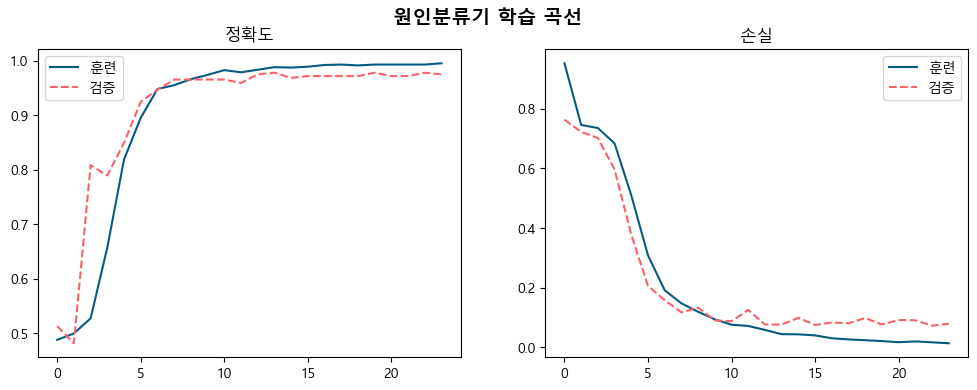

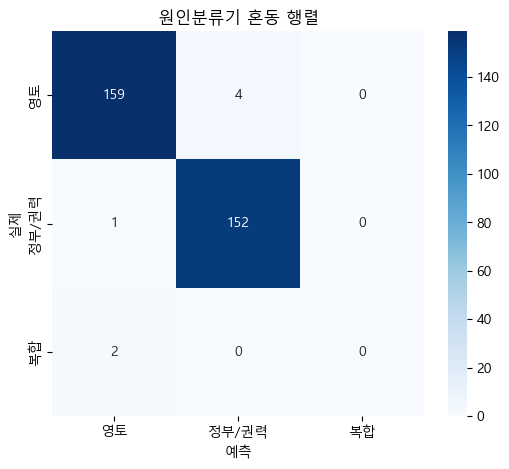


=== 2. 강도 분류기 학습 ===
Epoch 1/50
37/40 [==========================>...] - ETA: 0s - loss: 0.5548 - accuracy: 0.8032
Epoch 1: val_accuracy improved from -inf to 0.80189, saving model to models\risk_classifier_best.keras
40/40 [==============================] - 1s 9ms/step - loss: 0.5563 - accuracy: 0.7997 - val_loss: 0.4866 - val_accuracy: 0.8019
Epoch 2/50
34/40 [========================>.....] - ETA: 0s - loss: 0.4890 - accuracy: 0.8006
Epoch 2: val_accuracy did not improve from 0.80189
40/40 [==============================] - 0s 4ms/step - loss: 0.4864 - accuracy: 0.8028 - val_loss: 0.4779 - val_accuracy: 0.8019
Epoch 3/50
38/40 [===========================>..] - ETA: 0s - loss: 0.4591 - accuracy: 0.8043
Epoch 3: val_accuracy did not improve from 0.80189
40/40 [==============================] - 0s 4ms/step - loss: 0.4595 - accuracy: 0.8028 - val_loss: 0.4594 - val_accuracy: 0.8019
Epoch 4/50
40/40 [==============================] - ETA: 0s - loss: 0.4215 - accuracy: 0.8107
Epoch 4: v

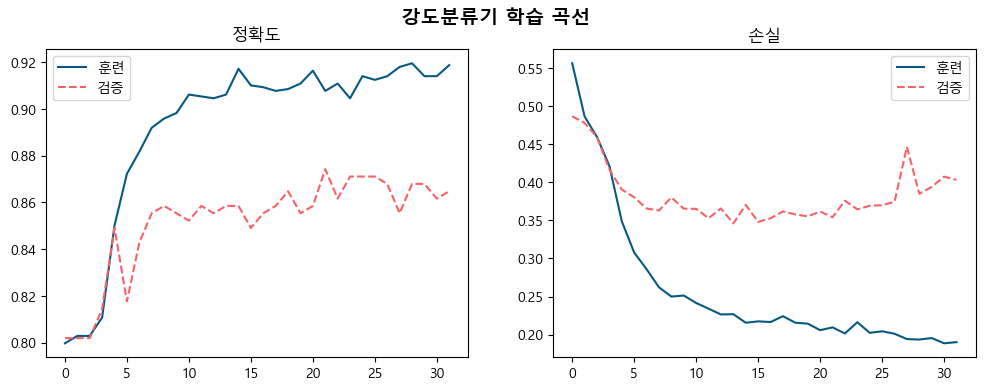

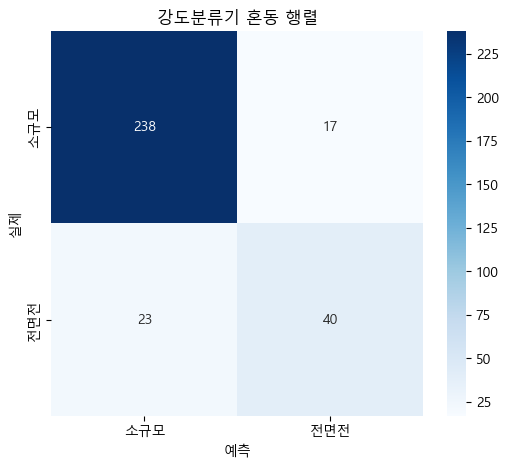

In [17]:
# 초심자 핵심: 에포크 도는 거 구경하는 셀. 발열 심해지니까 노트북 쿨러 켜라.
print("=== 1. 원인 분류기 학습 ===")
X_tr_c, X_te_c, yc_tr, yc_te = processor.split(X, y_cause)
cause_clf = ConflictClassifier(num_classes=3, name="cause_classifier")
cause_clf.build()
cause_clf.train(X_tr_c, yc_tr, X_te_c, yc_te)

yc_pred = cause_clf.evaluate(X_te_c, yc_te, ["영토", "정부/권력", "복합"])
viz.plot_training_history(cause_clf.history, "원인분류기")
viz.plot_confusion_matrix(yc_te, yc_pred, ["영토", "정부/권력", "복합"], "원인분류기")
cause_clf.save("models/cause_classifier.keras")

print("\n=== 2. 강도 분류기 학습 ===")
X_tr_r, X_te_r, yr_tr, yr_te = processor.split(X, y_risk)
risk_clf = ConflictClassifier(num_classes=2, name="risk_classifier")
risk_clf.build()
risk_clf.train(X_tr_r, yr_tr, X_te_r, yr_te)

yr_pred = risk_clf.evaluate(X_te_r, yr_te, ["소규모", "전면전"])
viz.plot_training_history(risk_clf.history, "강도분류기")
viz.plot_confusion_matrix(yr_te, yr_pred, ["소규모", "전면전"], "강도분류기")
risk_clf.save("models/risk_classifier.keras")

In [18]:
# 초심자 핵심: 나중에 RAG나 앱에서 쓰려면 토크나이저 저장 필수. 텍스트 바꿔가면서 테스트해봐라.
with open("models/tokenizer.pkl", "wb") as f:
    pickle.dump(processor.tokenizer, f)

test_text = "러시아 지역에서 러시아 정부 대 우크라이나 반군 간의 충돌"
print(f"🔍 입력: {test_text}")

cause_res = cause_clf.predict_one(test_text, processor.tokenizer, processor.cause_rev)
risk_res = risk_clf.predict_one(test_text, processor.tokenizer, processor.risk_rev)

print(f"👉 원인 예측: {cause_res['label']} ({cause_res['confidence']*100:.1f}%)")
print(f"👉 강도 예측: {risk_res['label']} ({risk_res['confidence']*100:.1f}%)")

🔍 입력: 러시아 지역에서 러시아 정부 대 우크라이나 반군 간의 충돌
👉 원인 예측: 정부/권력 (46.7%)
👉 강도 예측: 소규모 (69.8%)
